# Dyck-2 CFG Transformer next-token results and probes (len 0-2000)

This notebook mirrors the first training/probe cells from the Dyck-(2,3) CFG notebook, but runs only the Transformer. It keeps the same model spec and the same CFG next-token data-generation path, while setting `max_depth = max_length // 2` so the two-bracket Dyck language has no extra depth cap for lengths up to 2000. Set `RUN_TRAINING = True` only when intentionally generating the long run.


In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import torch

from hse.analysis.probes.linear import fit_logistic_probe, fit_ridge_probe
from hse.experiments.dyck2 import DYCK2_TRANSFORMER_MODEL_SPEC, run_dyck2_transformer_suite
from hse.tasks.dyck23 import Dyck23Config, Dyck23Sampler, validate_dyck23_tokens
from hse.utils.labels_io import load_labels


In [2]:
EXPERIMENT_NAME = 'dyck2_cfg_transformer_next_token_len_0_2000_memopt'
RESULTS_ROOT = ROOT / 'results' / EXPERIMENT_NAME
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_TYPES = ['transformer']
SEED = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

RUN_TRAINING = True # Set True only to intentionally train the Dyck-2 Transformer run.
ALLOW_OVERWRITE = False  # Keep False so existing artifacts fail fast instead of being rewritten.
TRAIN_EXAMPLES = 10_000
TEST_EXAMPLES = 512
PROBE_EXAMPLES = 512
TRAINING_STEPS = 15_000
EPOCHS = 20
# BATCH_SIZE is the effective batch; TRAIN_MICRO_BATCH_SIZE is what actually fits on the GPU.
BATCH_SIZE = 64
TRAIN_MICRO_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EXTRACT_BATCH_SIZE = 4
LEARNING_RATE = 3e-4
GRAD_CLIP = 5.0
AMP_DTYPE = 'bfloat16'
GRADIENT_CHECKPOINTING = True
MAX_PROBE_ROWS = 20_000

MIN_LENGTH = 0
MAX_LENGTH = 2000
MAX_DEPTH = MAX_LENGTH // 2
DYCK2_LENGTH_BINS = {
    'len_0_2000': {'min_length': MIN_LENGTH, 'max_length': MAX_LENGTH, 'max_depth': MAX_DEPTH},
}
# Keep the original variable name so copied Dyck23-style cells can stay simple.
DYCK23_LENGTH_BINS = DYCK2_LENGTH_BINS

BALANCE_PROBE_BY = 'depth_top_class'
PROBE_MIN_CLASS_COUNT = 8
PROBE_MAX_PER_CLASS = 128
FIXED_PREFIX_BY_BIN = {'len_0_2000': 1000}
SWEEP_PREFIX_BY_BIN = {'len_0_2000': list(range(100, MAX_LENGTH + 1, 100))}

RIDGE_TARGETS = [
    'left', 'right', 'height',
    'left_round', 'right_round', 'height_round',
    'left_square', 'right_square', 'height_square',
]
CLASS_TARGETS = ['top_type_class', 'depth_top_class', 'legal_next_class', 'height_class']

pd.DataFrame([
    {'model': 'transformer', **{k: v for k, v in DYCK2_TRANSFORMER_MODEL_SPEC.items() if k != 'state_kind'}}
])


,model,layers,emb_dim,hidden_dim,n_heads,ffn_dim,dropout,pos_encoding,embed_scale,final_layer_norm
0,transformer,5,32,32,8,128,0.1,sinusoidal,True,True


全局设置：只跑 `transformer`，模型结构取 `DYCK2_TRANSFORMER_MODEL_SPEC`，训练走 Dyck-2 专用的 `run_dyck2_transformer_suite` 省显存路径；数据仍由 `Dyck23Config`/`Dyck23Sampler` 的 CFG next-token 路径生成。`len_0_2000` 覆盖所有偶数 bracket length，`MAX_DEPTH=1000` 在这个长度范围内等价于 Dyck-2 没有额外深度限制。


## 1. Load or train the Dyck-2 Transformer run

Artifacts live under `results/dyck2_cfg_transformer_next_token_len_0_2000_memopt`. This cell only reads completed artifacts unless `RUN_TRAINING` is explicitly set to `True`; with `ALLOW_OVERWRITE = False`, it refuses to overwrite an existing long run.


In [3]:
runs_path = RESULTS_ROOT / 'runs.csv'
probe_path = RESULTS_ROOT / 'probe_summary.csv'
planned_run_dirs = [
    RESULTS_ROOT / length_bin / f'{model_type}_seed{SEED}'
    for length_bin in DYCK23_LENGTH_BINS
    for model_type in MODEL_TYPES
]
existing_artifacts = [
    path for path in [runs_path, probe_path, *planned_run_dirs]
    if path.exists()
]

if RUN_TRAINING and existing_artifacts and not ALLOW_OVERWRITE:
    raise FileExistsError(
        'Refusing to overwrite existing Dyck-2 artifacts. '
        f'Found {len(existing_artifacts)} existing path(s) under {RESULTS_ROOT}. '
        'Change EXPERIMENT_NAME, or set ALLOW_OVERWRITE = True only if overwriting is intentional. '
        f'First existing path: {existing_artifacts[0]}'
    )

if RUN_TRAINING:
    runs_df, probe_df = run_dyck2_transformer_suite(
        seed=SEED,
        length_bins=DYCK23_LENGTH_BINS,
        train_examples=TRAIN_EXAMPLES,
        test_examples=TEST_EXAMPLES,
        probe_examples=PROBE_EXAMPLES,
        steps=TRAINING_STEPS,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        train_micro_batch_size=TRAIN_MICRO_BATCH_SIZE,
        eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        grad_clip=GRAD_CLIP,
        extract_batch_size=EXTRACT_BATCH_SIZE,
        amp_dtype=AMP_DTYPE,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        max_probe_rows=MAX_PROBE_ROWS,
        device=DEVICE,
        results_root=RESULTS_ROOT,
        setting_name=EXPERIMENT_NAME,
    )
else:
    if not runs_path.exists() or not probe_path.exists():
        raise FileNotFoundError(
            f'Missing {runs_path} or {probe_path}. Set RUN_TRAINING = True only if you need to generate them.'
        )
    runs_df = pd.read_csv(runs_path)
    probe_df = pd.read_csv(probe_path)

expected_runs = len(MODEL_TYPES) * len(DYCK23_LENGTH_BINS)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    if (runs_path.exists() or probe_path.exists()) and not ALLOW_OVERWRITE:
        raise FileExistsError(
            'Summary CSVs have unexpected row counts, and ALLOW_OVERWRITE is False. '
            'Use a new EXPERIMENT_NAME or set ALLOW_OVERWRITE = True only if rewriting summaries is intentional.'
        )
    run_rows = []
    probe_rows = []
    for length_bin in DYCK23_LENGTH_BINS:
        for model_type in MODEL_TYPES:
            run_dir = RESULTS_ROOT / length_bin / f'{model_type}_seed{SEED}'
            config_path = run_dir / 'config.json'
            metrics_path = run_dir / 'metrics.json'
            if not config_path.exists() or not metrics_path.exists():
                raise FileNotFoundError(f'Missing completed artifacts under {run_dir}')
            config = json.load(open(config_path))
            metrics = json.load(open(metrics_path))
            labels_path = run_dir / 'labels.parquet'
            if labels_path.exists():
                hidden_rows = len(pd.read_parquet(labels_path, columns=['example_id']))
            else:
                hidden_rows = len(pd.read_csv(run_dir / 'labels.csv', usecols=['example_id']))
            eval_metrics = metrics['eval']
            hidden_dim = int(config['model'].get('hidden_dim', config['model'].get('emb_dim')))
            run_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                'run_dir': str(run_dir.resolve()),
                'loss': eval_metrics['loss'],
                'accuracy': eval_metrics['accuracy'],
                'dyck_accuracy': eval_metrics['dyck_accuracy'],
                'hidden_rows': hidden_rows,
                'hidden_dim': hidden_dim,
                'params': config['trainable_parameters'],
                'backbone_params': config['backbone_parameters_excluding_lm_head'],
                'elapsed_seconds': metrics.get('elapsed_seconds'),
            })
            probe_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                **metrics.get('probe', {}),
                **metrics.get('compression', {}),
            })
    runs_df = pd.DataFrame(run_rows)
    probe_df = pd.DataFrame(probe_rows)
    runs_df.to_csv(runs_path, index=False)
    probe_df.to_csv(probe_path, index=False)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    raise ValueError(f'Expected {expected_runs} runs/probe rows, got {len(runs_df)} and {len(probe_df)}.')

runs_df.sort_values(['length_bin', 'model']).reset_index(drop=True)



[len_0_2000] training Dyck-2 transformer (63,808 backbone params)
  step 00001/15000: train_loss=2.2602 test_loss=2.2376 acc=0.187
  step 01000/15000: train_loss=1.2731 test_loss=1.2180 acc=0.386
  step 02000/15000: train_loss=1.2158 test_loss=1.2091 acc=0.401
  step 03000/15000: train_loss=1.2103 test_loss=1.2057 acc=0.407
  step 04000/15000: train_loss=1.2079 test_loss=1.2034 acc=0.410
  step 05000/15000: train_loss=1.2062 test_loss=1.2015 acc=0.411
  step 06000/15000: train_loss=1.2043 test_loss=1.1986 acc=0.414
  step 07000/15000: train_loss=1.2024 test_loss=1.1968 acc=0.416
  step 08000/15000: train_loss=1.2008 test_loss=1.1940 acc=0.418
  step 09000/15000: train_loss=1.1992 test_loss=1.1921 acc=0.419
  step 10000/15000: train_loss=1.1980 test_loss=1.1914 acc=0.422
  step 11000/15000: train_loss=1.1966 test_loss=1.1895 acc=0.423
  step 12000/15000: train_loss=1.1955 test_loss=1.1865 acc=0.425
  step 13000/15000: train_loss=1.1943 test_loss=1.1855 acc=0.425
  step 14000/15000: tra

,length_bin,model,seed,run_dir,loss,accuracy,dyck_accuracy,hidden_rows,hidden_dim,params,backbone_params,elapsed_seconds
0,len_0_2000,transformer,0,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...,1.182303,0.4286,0.429034,531546,32,64039,63808,5655.355266


In [4]:
def load_run_arrays(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.is_absolute():
        candidates = [ROOT / run_dir, RESULTS_ROOT / run_dir]
        run_dir = next((path for path in candidates if (path / 'hidden_states.pt').exists()), ROOT / run_dir)
    hidden_path = run_dir / 'hidden_states.pt'
    if not hidden_path.exists():
        raise FileNotFoundError(f'Missing hidden states at {hidden_path}')
    hidden = torch.load(hidden_path, map_location='cpu').numpy()
    labels_path = run_dir / 'labels.parquet'
    if not labels_path.exists():
        labels_path = run_dir / 'labels.csv'
    labels = load_labels(labels_path)
    return {'X': hidden, 'labels': labels, 'run_dir': run_dir}


def select_prefix(data, prefix):
    labels = data['labels']
    mask = labels['dyck_seen'].to_numpy() == int(prefix)
    return {'X': data['X'][mask], 'labels': labels.loc[mask].reset_index(drop=True), 'run_dir': data['run_dir']}


def balance_data_by_label(data, label=BALANCE_PROBE_BY, seed=0, max_per_class=PROBE_MAX_PER_CLASS, min_per_class=PROBE_MIN_CLASS_COUNT):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby(label).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_class:
            continue
        take = min(len(idx), max_per_class) if max_per_class else len(idx)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def run_stack_probes(data, seed=0):
    X = data['X']
    labels = data['labels']
    rows = []
    if len(labels) < 4:
        return pd.DataFrame(rows)

    for target in RIDGE_TARGETS:
        if target not in labels or labels[target].nunique() <= 1:
            continue
        result = fit_ridge_probe(X, labels[target].to_numpy(), seed=seed)
        rows.append({
            'probe_type': 'ridge',
            'target': target,
            'r2': result.get('r2'),
            'mae': result.get('mae'),
            'n_rows': len(labels),
        })

    for target in CLASS_TARGETS:
        if target not in labels or labels[target].nunique() <= 1:
            continue
        counts = labels[target].value_counts()
        keep_values = counts[counts >= PROBE_MIN_CLASS_COUNT].index
        keep = labels[target].isin(keep_values).to_numpy()
        if keep.sum() < 4 or len(keep_values) < 2:
            continue
        result = fit_logistic_probe(X[keep], labels[target].to_numpy()[keep], seed=seed)
        rows.append({
            'probe_type': 'logistic',
            'target': target,
            'accuracy': result.get('accuracy'),
            'n_classes': int(len(keep_values)),
            'n_rows': int(keep.sum()),
        })
    return pd.DataFrame(rows)


run_arrays = {
    (row.length_bin, row.model): load_run_arrays(row.run_dir)
    for row in runs_df.itertuples()
}

fixed_probe_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    prefix = FIXED_PREFIX_BY_BIN[length_bin]
    for model_type in MODEL_TYPES:
        data = select_prefix(run_arrays[(length_bin, model_type)], prefix)
        data = balance_data_by_label(data, seed=SEED)
        rows = run_stack_probes(data, seed=SEED)
        if len(rows):
            rows.insert(0, 'prefix', prefix)
            rows.insert(0, 'model', model_type)
            rows.insert(0, 'length_bin', length_bin)
            fixed_probe_rows.append(rows)

fixed_probe_df = pd.concat(fixed_probe_rows, ignore_index=True) if fixed_probe_rows else pd.DataFrame()
fixed_probe_path = RESULTS_ROOT / 'fixed_prefix_probe_summary.csv'
fixed_probe_df.to_csv(fixed_probe_path, index=False)
fixed_probe_df


,length_bin,model,prefix,probe_type,target,r2,mae,n_rows,accuracy,n_classes
0,len_0_2000,transformer,1000,ridge,left,0.604174,1.481312,118,NaN,NaN
1,len_0_2000,transformer,1000,ridge,right,0.604174,1.481312,118,NaN,NaN
2,len_0_2000,transformer,1000,ridge,height,0.604174,2.962625,118,NaN,NaN
3,len_0_2000,transformer,1000,ridge,left_round,0.332527,7.716351,118,NaN,NaN
4,len_0_2000,transformer,1000,ridge,right_round,0.382413,7.792001,118,NaN,NaN
5,len_0_2000,transformer,1000,ridge,height_round,0.497016,1.889944,118,NaN,NaN
6,len_0_2000,transformer,1000,ridge,left_square,0.340636,8.050983,118,NaN,NaN
7,len_0_2000,transformer,1000,ridge,right_square,0.389220,7.470541,118,NaN,NaN
8,len_0_2000,transformer,1000,ridge,height_square,0.609573,2.030010,118,NaN,NaN
9,len_0_2000,transformer,1000,logistic,top_type_class,NaN,NaN,118,0.766667,2.0


## 2. Counter geometry visualizations

These cells mirror the Dyck / Dyck-k visualization style for the Dyck-2 Transformer run: supervised counter lattice projections, counter-direction orthogonality summaries, prefix sweeps of the counter basis, and interactive 3D HTML views of `(height_round, height_square)` counter categories.


In [5]:
import matplotlib.pyplot as plt
from hse.analysis.probes.linear import extract_linear_weight

COUNTER_TARGET_PAIRS = [('height_round', 'height_square')]
COUNTER_TOTAL_TARGETS = {('height_round', 'height_square'): 'height'}
COUNTER_MIN_PER_PAIR = 6
COUNTER_MAX_PER_PAIR = 256
COUNTER_PLOT_MAX_POINTS = 7_000
COUNTER_HTML_MAX_POINTS = 12_000
COUNTER_HTML_MAX_CENTROIDS = 1_500


def finalize_figure(fig, section, stem):
    out_dir = FIGURES_ROOT / section
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{stem}.png'
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'saved figure -> {out_path}')


def _unit(vec):
    vec = np.asarray(vec, dtype=float)
    return vec / (np.linalg.norm(vec) + 1e-12)


def cosine(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(a @ b / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))


def balance_data_by_counter_pair(
    data,
    x_target='height_round',
    y_target='height_square',
    seed=0,
    max_per_pair=COUNTER_MAX_PER_PAIR,
    min_per_pair=COUNTER_MIN_PER_PAIR,
):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby([x_target, y_target]).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_pair:
            continue
        take = min(len(idx), max_per_pair) if max_per_pair else len(idx)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def fit_counter_directions(data, targets=('height', 'height_round', 'height_square'), seed=0):
    X = data['X']
    labels = data['labels']
    results = {}
    directions = {}
    for target in targets:
        if target not in labels or labels[target].nunique() <= 1 or len(labels) < 4:
            continue
        result = fit_ridge_probe(X, labels[target].to_numpy(), seed=seed)
        weight = extract_linear_weight(result.get('probe'))
        if weight.ndim == 1 and weight.size:
            results[target] = result
            directions[target] = weight
    return results, directions


def summarize_counter_orthogonality(directions, *, length_bin, model_type, prefix, x_target='height_round', y_target='height_square'):
    row = {'length_bin': length_bin, 'model': model_type, 'prefix': prefix, 'x_target': x_target, 'y_target': y_target}
    if x_target not in directions or y_target not in directions:
        return row
    wx = directions[x_target]
    wy = directions[y_target]
    w_sum = wx + wy
    w_diff = wx - wy
    row['cosine'] = cosine(wx, wy)
    row['abs_cosine'] = abs(row['cosine'])
    row['cos_sum_diff'] = cosine(w_sum, w_diff)
    row['abs_cos_sum_diff'] = abs(row['cos_sum_diff'])
    total_target = COUNTER_TOTAL_TARGETS.get((x_target, y_target))
    if total_target in directions:
        row['cos_total_sum'] = cosine(directions[total_target], w_sum)
        row['cos_total_diff'] = cosine(directions[total_target], w_diff)
    return row


def counter_centroids(data, x_target='height_round', y_target='height_square', min_count=COUNTER_MIN_PER_PAIR):
    labels = data['labels'].reset_index(drop=True)
    X = np.asarray(data['X'], dtype=float)
    rows = []
    vectors = []
    for (x_value, y_value), group in labels.groupby([x_target, y_target]):
        idx = group.index.to_numpy()
        if len(idx) < min_count:
            continue
        vectors.append(X[idx].mean(axis=0))
        rows.append({
            x_target: int(x_value),
            y_target: int(y_value),
            'total_height': int(x_value + y_value),
            'n': int(len(idx)),
            'counter_label': f'({int(x_value)}, {int(y_value)})',
        })
    if not rows:
        return pd.DataFrame(), np.empty((0, X.shape[1] if X.ndim == 2 else 0))
    return pd.DataFrame(rows), np.stack(vectors, axis=0)


def _pca_basis_from_means(means, dims=3):
    means = np.asarray(means, dtype=float)
    center = means.mean(axis=0, keepdims=True)
    centered = means - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    basis = vt[: min(dims, vt.shape[0])]
    if basis.shape[0] < dims:
        basis = np.pad(basis, ((0, dims - basis.shape[0]), (0, 0)), mode='constant')
    return center.squeeze(0), basis


def _sample_rows(n, max_points, seed=0):
    if max_points is None or n <= max_points:
        return np.arange(n)
    return np.sort(np.random.default_rng(seed).choice(n, size=int(max_points), replace=False))


def plot_counter_lattice_projection(
    data,
    directions,
    *,
    length_bin,
    model_type,
    prefix='all',
    x_target='height_round',
    y_target='height_square',
    max_points=COUNTER_PLOT_MAX_POINTS,
):
    if x_target not in directions or y_target not in directions:
        print(f'skip lattice projection: missing {x_target}/{y_target} directions')
        return
    labels = data['labels'].reset_index(drop=True)
    X = np.asarray(data['X'], dtype=float)
    idx = _sample_rows(len(labels), max_points, seed=SEED)
    wx = _unit(directions[x_target])
    wy = _unit(directions[y_target])
    Z = np.stack([X[idx] @ wx, X[idx] @ wy], axis=1)
    sub = labels.iloc[idx].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(6.3, 5.2))
    color = sub[x_target].to_numpy() + sub[y_target].to_numpy()
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=color, s=7, cmap='viridis', alpha=0.22, edgecolors='none')

    centroid_df, _ = counter_centroids({'X': X, 'labels': labels, 'run_dir': data['run_dir']}, x_target, y_target)
    if len(centroid_df):
        centroid_xy = []
        for _, group in labels.groupby([x_target, y_target]):
            gidx = group.index.to_numpy()
            if len(gidx) >= COUNTER_MIN_PER_PAIR:
                centroid_xy.append([float((X[gidx] @ wx).mean()), float((X[gidx] @ wy).mean())])
        centroid_xy = np.asarray(centroid_xy)
        ax.scatter(centroid_xy[:, 0], centroid_xy[:, 1], c=centroid_df['total_height'], cmap='viridis', s=48, edgecolors='black', linewidths=0.45)
    ax.set_xlabel(f'{x_target} direction')
    ax.set_ylabel(f'{y_target} direction')
    ax.set_title(f'{length_bin} | {model_type} | prefix={prefix}\n{x_target} vs {y_target}')
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('total height')
    finalize_figure(fig, 'counter_lattices', f'{length_bin}_{model_type}_prefix{prefix}_{x_target}_vs_{y_target}')
    plt.show()
    plt.close(fig)


def build_counter_category_3d_html(
    data,
    *,
    length_bin,
    model_type,
    prefix='all',
    x_target='height_round',
    y_target='height_square',
    max_points=COUNTER_HTML_MAX_POINTS,
    max_centroids=COUNTER_HTML_MAX_CENTROIDS,
):
    labels = data['labels'].reset_index(drop=True)
    X = np.asarray(data['X'], dtype=float)
    centroid_df, centroid_vectors = counter_centroids(data, x_target, y_target)
    if len(centroid_df) < 2:
        raise ValueError('Need at least two counter classes for 3D counter HTML.')
    if len(centroid_df) > max_centroids:
        keep = centroid_df.sort_values('n', ascending=False).head(max_centroids).sort_index().index.to_numpy()
        centroid_df = centroid_df.iloc[keep].reset_index(drop=True)
        centroid_vectors = centroid_vectors[keep]

    center, basis = _pca_basis_from_means(centroid_vectors, dims=3)
    sample_idx = _sample_rows(len(labels), max_points, seed=SEED)
    sample_coords = (X[sample_idx] - center) @ basis.T
    sample_labels = labels.iloc[sample_idx].reset_index(drop=True)
    mean_coords = (centroid_vectors - center) @ basis.T

    sample_text = [
        f'{x_target}={int(x)}, {y_target}={int(y)}, total={int(x + y)}'
        for x, y in zip(sample_labels[x_target].to_numpy(), sample_labels[y_target].to_numpy())
    ]
    payload = {
        'sample': {
            'x': sample_coords[:, 0].astype(float).tolist(),
            'y': sample_coords[:, 1].astype(float).tolist(),
            'z': sample_coords[:, 2].astype(float).tolist(),
            'total': (sample_labels[x_target].to_numpy() + sample_labels[y_target].to_numpy()).astype(int).tolist(),
            'text': sample_text,
        },
        'mean': {
            'x': mean_coords[:, 0].astype(float).tolist(),
            'y': mean_coords[:, 1].astype(float).tolist(),
            'z': mean_coords[:, 2].astype(float).tolist(),
            'total': centroid_df['total_height'].astype(int).tolist(),
            'n': centroid_df['n'].astype(int).tolist(),
            'text': centroid_df['counter_label'].tolist(),
        },
        'meta': {
            'length_bin': length_bin,
            'model': model_type,
            'prefix': str(prefix),
            'x_target': x_target,
            'y_target': y_target,
            'n_samples': int(len(sample_idx)),
            'n_counter_classes': int(len(centroid_df)),
        },
    }
    payload_json = json.dumps(payload)
    html = """<!DOCTYPE html>
<html lang=\"en\">
<head>
  <meta charset=\"utf-8\" />
  <title>__TITLE__</title>
  <script src=\"https://cdn.plot.ly/plotly-2.35.2.min.js\"></script>
  <style>
    body { font-family: Arial, sans-serif; margin: 0; background: #f8f7f4; color: #202124; }
    .wrap { max-width: 1400px; margin: 0 auto; padding: 20px 24px 28px; }
    h1 { margin: 0 0 8px; font-size: 26px; }
    .sub { margin: 0 0 14px; color: #4b5563; line-height: 1.5; }
    #plot { width: 100%; height: 78vh; min-height: 720px; border-radius: 12px; overflow: hidden; background: white; box-shadow: 0 10px 30px rgba(0,0,0,0.08); }
  </style>
</head>
<body>
  <div class=\"wrap\">
    <h1>__TITLE__</h1>
    <p class=\"sub\">Hidden states are projected onto the first three principal directions of counter-category centroids. Large labeled markers are centroids for (__X_TARGET__, __Y_TARGET__) classes; small markers are sampled prefix states.</p>
    <div id=\"plot\"></div>
  </div>
  <script>
    const payload = __PAYLOAD__;
    const sampleTrace = {
      type: 'scatter3d',
      mode: 'markers',
      name: 'prefix states',
      x: payload.sample.x,
      y: payload.sample.y,
      z: payload.sample.z,
      text: payload.sample.text,
      marker: {
        size: 2.5,
        opacity: 0.16,
        color: payload.sample.total,
        colorscale: 'Viridis',
        colorbar: { title: 'total height' },
      },
      hovertemplate: '%{text}<br>pc1=%{x:.3f}<br>pc2=%{y:.3f}<br>pc3=%{z:.3f}<extra></extra>',
    };
    const centroidTrace = {
      type: 'scatter3d',
      mode: 'markers+text',
      name: 'counter centroids',
      x: payload.mean.x,
      y: payload.mean.y,
      z: payload.mean.z,
      text: payload.mean.text,
      textposition: 'top center',
      marker: {
        size: 7,
        color: payload.mean.total,
        colorscale: 'Viridis',
        line: { color: '#111827', width: 1 },
      },
      customdata: payload.mean.n,
      hovertemplate: 'counter=%{text}<br>n=%{customdata}<br>pc1=%{x:.3f}<br>pc2=%{y:.3f}<br>pc3=%{z:.3f}<extra></extra>',
    };
    const layout = {
      margin: { l: 0, r: 0, t: 20, b: 0 },
      paper_bgcolor: '#f8f7f4',
      plot_bgcolor: '#ffffff',
      legend: { orientation: 'h', y: 1.02, x: 0.0 },
      scene: {
        xaxis: { title: 'counter mean-PC1', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' },
        yaxis: { title: 'counter mean-PC2', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' },
        zaxis: { title: 'counter mean-PC3', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' },
        camera: { eye: { x: 1.45, y: 1.55, z: 0.95 } },
        aspectmode: 'data',
      },
    };
    Plotly.newPlot('plot', [sampleTrace, centroidTrace], layout, {responsive: true, displaylogo: false});
  </script>
</body>
</html>
"""
    title = f'{length_bin} | {model_type} | prefix={prefix} | counter-category 3D'
    return (
        html.replace('__TITLE__', title)
        .replace('__X_TARGET__', x_target)
        .replace('__Y_TARGET__', y_target)
        .replace('__PAYLOAD__', payload_json)
    )


def export_counter_category_3d_html(data, *, length_bin, model_type, prefix='all', x_target='height_round', y_target='height_square'):
    out_dir = RESULTS_ROOT / 'counter_3d_html'
    out_dir.mkdir(parents=True, exist_ok=True)
    html = build_counter_category_3d_html(data, length_bin=length_bin, model_type=model_type, prefix=prefix, x_target=x_target, y_target=y_target)
    out_path = out_dir / f'{length_bin}_{model_type}_prefix{prefix}_{x_target}_vs_{y_target}_counter3d.html'
    out_path.write_text(html, encoding='utf-8')
    print(f'saved counter 3D HTML -> {out_path}')
    return out_path


saved figure -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/figures/counter_lattices/len_0_2000_transformer_prefixall_height_round_vs_height_square.png


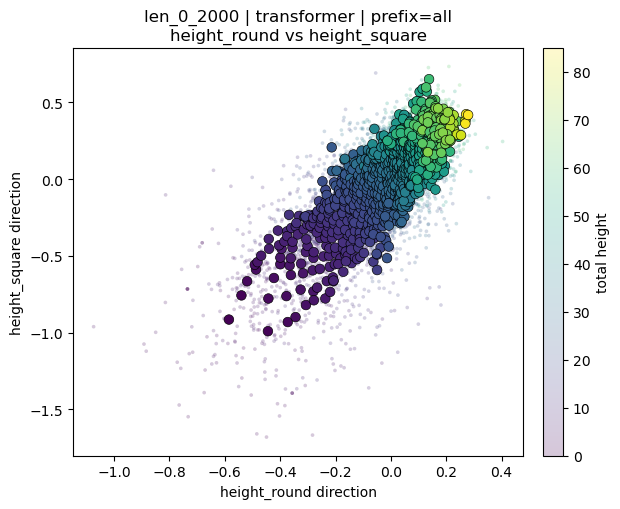

saved counter 3D HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_3d_html/len_0_2000_transformer_prefixall_height_round_vs_height_square_counter3d.html
saved figure -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/figures/counter_lattices/len_0_2000_transformer_prefix1000_height_round_vs_height_square.png


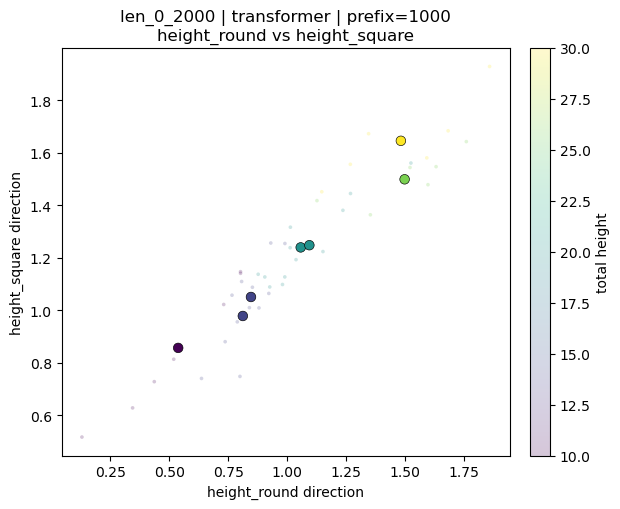

saved counter 3D HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_3d_html/len_0_2000_transformer_prefix1000_height_round_vs_height_square_counter3d.html
saved summary -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_orthogonality_summary.csv


,length_bin,model,prefix,x_target,y_target,cosine,abs_cosine,cos_sum_diff,abs_cos_sum_diff,cos_total_sum,cos_total_diff,n_rows,view
0,len_0_2000,transformer,all,height_round,height_square,0.492085,0.492085,0.619526,0.619526,1.0,0.619526,140758,all_prefixes
1,len_0_2000,transformer,1000,height_round,height_square,0.673459,0.673459,0.071973,0.071973,1.0,0.071973,44,fixed_prefix


In [6]:
counter_visual_rows = []
counter_html_paths = []

for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        raw = run_arrays[(length_bin, model_type)]
        all_prefix_data = balance_data_by_counter_pair(raw, seed=SEED)
        _, all_prefix_dirs = fit_counter_directions(all_prefix_data, seed=SEED)
        counter_visual_rows.append({
            **summarize_counter_orthogonality(all_prefix_dirs, length_bin=length_bin, model_type=model_type, prefix='all'),
            'n_rows': len(all_prefix_data['labels']),
            'view': 'all_prefixes',
        })
        plot_counter_lattice_projection(
            all_prefix_data,
            all_prefix_dirs,
            length_bin=length_bin,
            model_type=model_type,
            prefix='all',
        )
        counter_html_paths.append(
            export_counter_category_3d_html(
                all_prefix_data,
                length_bin=length_bin,
                model_type=model_type,
                prefix='all',
            )
        )

        fixed_prefix = FIXED_PREFIX_BY_BIN[length_bin]
        fixed_data = balance_data_by_counter_pair(select_prefix(raw, fixed_prefix), seed=SEED)
        _, fixed_dirs = fit_counter_directions(fixed_data, seed=SEED)
        counter_visual_rows.append({
            **summarize_counter_orthogonality(fixed_dirs, length_bin=length_bin, model_type=model_type, prefix=fixed_prefix),
            'n_rows': len(fixed_data['labels']),
            'view': 'fixed_prefix',
        })
        plot_counter_lattice_projection(
            fixed_data,
            fixed_dirs,
            length_bin=length_bin,
            model_type=model_type,
            prefix=fixed_prefix,
        )
        counter_html_paths.append(
            export_counter_category_3d_html(
                fixed_data,
                length_bin=length_bin,
                model_type=model_type,
                prefix=fixed_prefix,
            )
        )

counter_orthogonality_df = pd.DataFrame(counter_visual_rows)
counter_orthogonality_path = RESULTS_ROOT / 'counter_orthogonality_summary.csv'
counter_orthogonality_df.to_csv(counter_orthogonality_path, index=False)
print(f'saved summary -> {counter_orthogonality_path}')
counter_orthogonality_df


saved figure -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/figures/counter_orthogonality/counter_orthogonality_bars.png


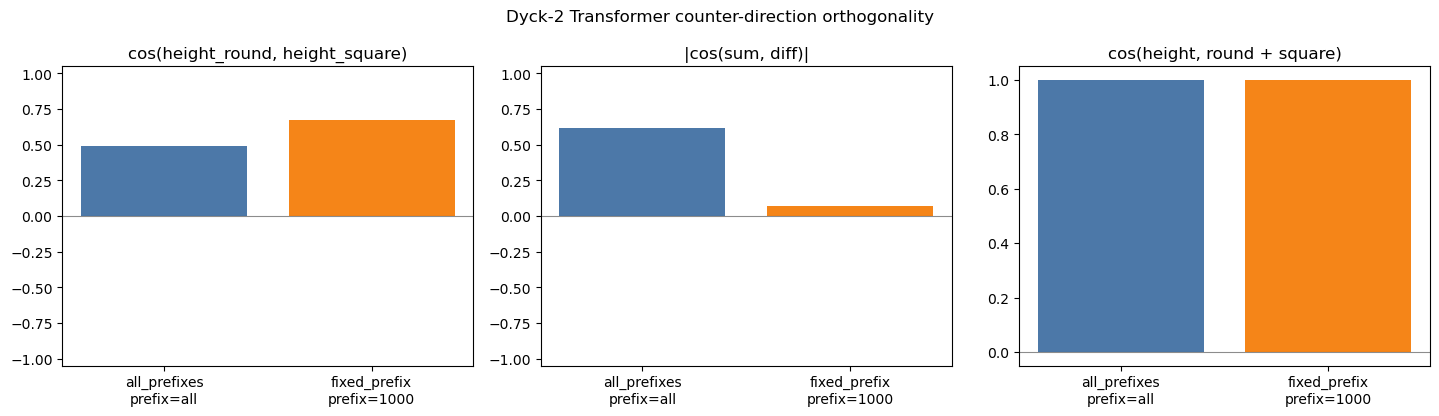

In [7]:
def plot_counter_orthogonality_bars(df):
    metrics = [
        ('cosine', 'cos(height_round, height_square)'),
        ('abs_cos_sum_diff', '|cos(sum, diff)|'),
        ('cos_total_sum', 'cos(height, round + square)'),
    ]
    plot_df = df.loc[df['view'].isin(['all_prefixes', 'fixed_prefix'])].copy()
    if plot_df.empty:
        return
    fig, axes = plt.subplots(1, len(metrics), figsize=(14.5, 4.2), sharey=False)
    for ax, (metric, title) in zip(axes, metrics):
        sub = plot_df.dropna(subset=[metric]) if metric in plot_df else pd.DataFrame()
        if sub.empty:
            ax.set_axis_off()
            continue
        labels = [f"{row.view}\nprefix={row.prefix}" for row in sub.itertuples()]
        colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756']
        ax.bar(np.arange(len(sub)), sub[metric].to_numpy(), color=colors[:len(sub)])
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.45)
        if metric != 'cos_total_sum':
            ax.set_ylim(-1.05, 1.05)
        else:
            ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(np.arange(len(sub)), labels, rotation=0)
        ax.set_title(title)
    fig.suptitle('Dyck-2 Transformer counter-direction orthogonality')
    finalize_figure(fig, 'counter_orthogonality', 'counter_orthogonality_bars')
    plt.show()
    plt.close(fig)


plot_counter_orthogonality_bars(counter_orthogonality_df)


saved summary -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/direction_arithmetic_summary.csv
saved figure -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/figures/counter_orthogonality/counter_orthogonality_prefix_sweep.png


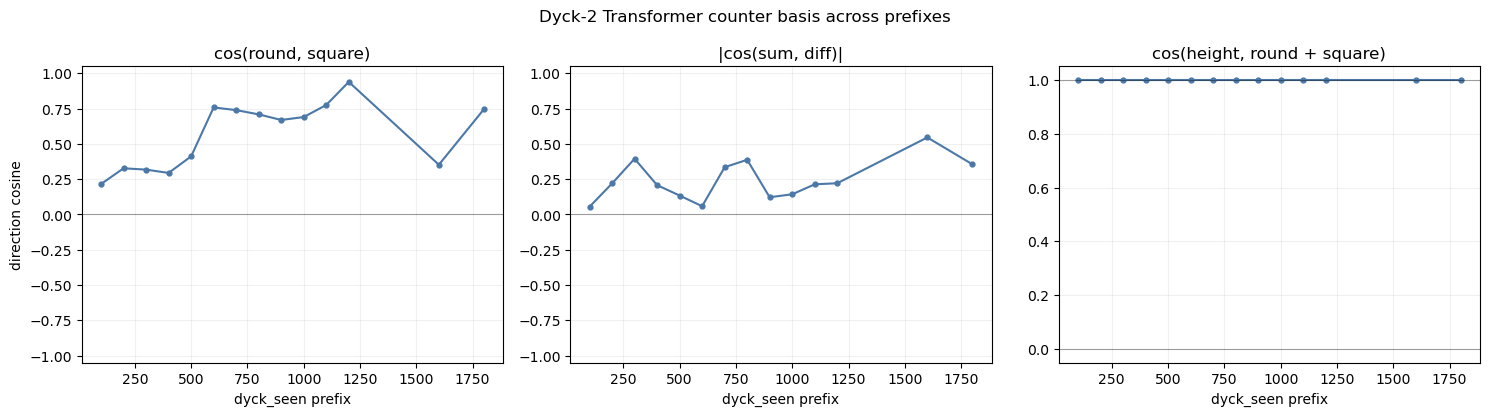

,length_bin,model,prefix,x_target,y_target,cosine,abs_cosine,cos_sum_diff,abs_cos_sum_diff,cos_total_sum,cos_total_diff,n_rows
0,len_0_2000,transformer,100,height_round,height_square,0.215601,0.215601,-0.054572,0.054572,1.0,-0.054572,404
1,len_0_2000,transformer,200,height_round,height_square,0.327260,0.327260,0.219498,0.219498,1.0,0.219498,342
2,len_0_2000,transformer,300,height_round,height_square,0.317878,0.317878,0.395024,0.395024,1.0,0.395024,286
3,len_0_2000,transformer,400,height_round,height_square,0.294327,0.294327,0.207892,0.207892,1.0,0.207892,213
4,len_0_2000,transformer,500,height_round,height_square,0.411839,0.411839,0.134144,0.134144,1.0,0.134144,150
5,len_0_2000,transformer,600,height_round,height_square,0.758484,0.758484,-0.058407,0.058407,1.0,-0.058407,160
6,len_0_2000,transformer,700,height_round,height_square,0.739670,0.739670,-0.334961,0.334961,1.0,-0.334961,117
7,len_0_2000,transformer,800,height_round,height_square,0.709472,0.709472,0.387495,0.387495,1.0,0.387495,102
8,len_0_2000,transformer,900,height_round,height_square,0.669707,0.669707,0.121910,0.121910,1.0,0.121910,104
9,len_0_2000,transformer,1000,height_round,height_square,0.690509,0.690509,0.143044,0.143044,1.0,0.143044,81


In [8]:
direction_sweep_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    raw = run_arrays[(length_bin, 'transformer')]
    for prefix in SWEEP_PREFIX_BY_BIN[length_bin]:
        data = select_prefix(raw, prefix)
        data = balance_data_by_counter_pair(data, seed=SEED, max_per_pair=128, min_per_pair=4)
        if len(data['labels']) < 32:
            continue
        _, directions = fit_counter_directions(data, seed=SEED)
        row = summarize_counter_orthogonality(directions, length_bin=length_bin, model_type='transformer', prefix=prefix)
        row['n_rows'] = len(data['labels'])
        direction_sweep_rows.append(row)

direction_arithmetic_df = pd.DataFrame(direction_sweep_rows)
direction_arithmetic_path = RESULTS_ROOT / 'direction_arithmetic_summary.csv'
direction_arithmetic_df.to_csv(direction_arithmetic_path, index=False)
print(f'saved summary -> {direction_arithmetic_path}')

if not direction_arithmetic_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
    metrics = [
        ('cosine', 'cos(round, square)'),
        ('abs_cos_sum_diff', '|cos(sum, diff)|'),
        ('cos_total_sum', 'cos(height, round + square)'),
    ]
    for ax, (metric, title) in zip(axes, metrics):
        if metric not in direction_arithmetic_df:
            ax.set_axis_off()
            continue
        sub = direction_arithmetic_df.sort_values('prefix')
        ax.plot(sub['prefix'], sub[metric], marker='o', ms=3.5, color='#4c78a8')
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.35)
        if metric == 'cos_total_sum':
            ax.axhline(1.0, color='black', lw=0.8, alpha=0.35)
            ax.set_ylim(-0.05, 1.05)
        else:
            ax.set_ylim(-1.05, 1.05)
        ax.set_title(title)
        ax.set_xlabel('dyck_seen prefix')
        ax.grid(True, alpha=0.18)
    axes[0].set_ylabel('direction cosine')
    fig.suptitle('Dyck-2 Transformer counter basis across prefixes')
    finalize_figure(fig, 'counter_orthogonality', 'counter_orthogonality_prefix_sweep')
    plt.show()
    plt.close(fig)

direction_arithmetic_df


In [9]:
# White-background height-colored 3D HTML exports.
# Per-type view uses higher-contrast custom ramps; total-height view keeps the earlier Viridis style.
COUNTER_HEIGHT_HTML_POINTS = 15_000


def _counter_height_projection(data, *, x_target='height_round', y_target='height_square'):
    labels = data['labels'].reset_index(drop=True)
    X = np.asarray(data['X'], dtype=float)
    centroid_df, centroid_vectors = counter_centroids(data, x_target, y_target, min_count=max(2, COUNTER_MIN_PER_PAIR))
    if len(centroid_df) >= 2:
        center, basis = _pca_basis_from_means(centroid_vectors, dims=3)
    else:
        center, basis = _pca_basis_from_means(X[_sample_rows(len(X), min(len(X), 2_000), seed=SEED)], dims=3)
    coords = (X - center) @ basis.T
    return coords, labels


def _height_payload(data, *, length_bin, model_type, prefix, max_points=COUNTER_HEIGHT_HTML_POINTS):
    coords, labels = _counter_height_projection(data)
    idx = _sample_rows(len(labels), max_points, seed=SEED)
    sub = labels.iloc[idx].reset_index(drop=True)
    pts = coords[idx]
    round_height = sub['height_round'].to_numpy(dtype=int)
    square_height = sub['height_square'].to_numpy(dtype=int)
    total_height = sub['height'].to_numpy(dtype=int) if 'height' in sub else round_height + square_height
    text = [
        f'round={int(r)}, square={int(s)}, total={int(t)}'
        for r, s, t in zip(round_height, square_height, total_height)
    ]
    return {
        'x': pts[:, 0].astype(float).tolist(),
        'y': pts[:, 1].astype(float).tolist(),
        'z': pts[:, 2].astype(float).tolist(),
        'round_height': round_height.tolist(),
        'square_height': square_height.tolist(),
        'total_height': total_height.tolist(),
        'text': text,
        'meta': {
            'length_bin': length_bin,
            'model': model_type,
            'prefix': str(prefix),
            'n_points': int(len(idx)),
        },
    }


def _height_point_opacity(payload):
    return 0.30 if payload['meta']['prefix'] == 'all' else 0.62


def _height_point_size(payload):
    return 2.7 if payload['meta']['prefix'] == 'all' else 4.1


def build_per_type_height_3d_html(payload, *, title):
    payload_json = json.dumps(payload)
    html = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <title>__TITLE__</title>
  <script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
  <style>
    body { font-family: Arial, sans-serif; margin: 0; background: #f7f7f5; color: #151922; }
    .wrap { max-width: 1480px; margin: 0 auto; padding: 20px 24px 28px; }
    h1 { margin: 0 0 8px; font-size: 26px; }
    .sub { margin: 0 0 14px; color: #4b5563; line-height: 1.5; }
    #plot { width: 100%; height: 78vh; min-height: 720px; border-radius: 12px; overflow: hidden; background: white; box-shadow: 0 10px 30px rgba(0,0,0,0.08); }
  </style>
</head>
<body>
  <div class="wrap">
    <h1>__TITLE__</h1>
    <p class="sub">Same 3D projection shown twice. Left colors each point by round height; right colors each point by square height. Low values are intentionally dark so they remain visible on white.</p>
    <div id="plot"></div>
  </div>
  <script>
    const payload = __PAYLOAD__;
    const pointOpacity = __OPACITY__;
    const pointSize = __SIZE__;
    const roundScale = [
      [0.00, '#172554'],
      [0.16, '#1d4ed8'],
      [0.32, '#0891b2'],
      [0.50, '#10b981'],
      [0.68, '#a3e635'],
      [0.84, '#facc15'],
      [1.00, '#f97316'],
    ];
    const squareScale = [
      [0.00, '#3b0764'],
      [0.16, '#7e22ce'],
      [0.32, '#db2777'],
      [0.50, '#ef4444'],
      [0.68, '#f97316'],
      [0.84, '#facc15'],
      [1.00, '#854d0e'],
    ];
    function traceFor(sceneName, colorValues, colorscale, name, colorbarX) {
      return {
        type: 'scatter3d',
        mode: 'markers',
        name: name,
        scene: sceneName,
        x: payload.x,
        y: payload.y,
        z: payload.z,
        text: payload.text,
        marker: {
          size: pointSize,
          opacity: pointOpacity,
          color: colorValues,
          colorscale: colorscale,
          cmin: 0,
          cmax: Math.max(...colorValues),
          colorbar: { title: name, x: colorbarX, len: 0.74 },
        },
        hovertemplate: '%{text}<br>pc1=%{x:.3f}<br>pc2=%{y:.3f}<br>pc3=%{z:.3f}<extra></extra>',
      };
    }
    const traces = [
      traceFor('scene', payload.round_height, roundScale, 'height_round', 0.46),
      traceFor('scene2', payload.square_height, squareScale, 'height_square', 1.0),
    ];
    const axisStyle = { backgroundcolor: '#ffffff', gridcolor: '#dbe3ee', zerolinecolor: '#94a3b8', color: '#374151' };
    const layout = {
      margin: { l: 0, r: 0, t: 40, b: 0 },
      paper_bgcolor: '#ffffff',
      plot_bgcolor: '#ffffff',
      showlegend: false,
      annotations: [
        { text: 'colored by height_round', x: 0.22, y: 1.02, xref: 'paper', yref: 'paper', showarrow: false, font: { size: 16 } },
        { text: 'colored by height_square', x: 0.78, y: 1.02, xref: 'paper', yref: 'paper', showarrow: false, font: { size: 16 } },
      ],
      scene: {
        domain: { x: [0.0, 0.47], y: [0.0, 1.0] },
        xaxis: { title: 'counter mean-PC1', ...axisStyle },
        yaxis: { title: 'counter mean-PC2', ...axisStyle },
        zaxis: { title: 'counter mean-PC3', ...axisStyle },
        camera: { eye: { x: 1.45, y: 1.55, z: 0.95 } },
        aspectmode: 'data',
      },
      scene2: {
        domain: { x: [0.53, 1.0], y: [0.0, 1.0] },
        xaxis: { title: 'counter mean-PC1', ...axisStyle },
        yaxis: { title: 'counter mean-PC2', ...axisStyle },
        zaxis: { title: 'counter mean-PC3', ...axisStyle },
        camera: { eye: { x: 1.45, y: 1.55, z: 0.95 } },
        aspectmode: 'data',
      },
    };
    Plotly.newPlot('plot', traces, layout, {responsive: true, displaylogo: false});
  </script>
</body>
</html>
"""
    return (
        html.replace('__TITLE__', title)
        .replace('__PAYLOAD__', payload_json)
        .replace('__OPACITY__', str(_height_point_opacity(payload)))
        .replace('__SIZE__', str(_height_point_size(payload)))
    )


def build_total_height_3d_html(payload, *, title):
    payload_json = json.dumps(payload)
    html = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <title>__TITLE__</title>
  <script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
  <style>
    body { font-family: Arial, sans-serif; margin: 0; background: #f8f7f4; color: #202124; }
    .wrap { max-width: 1320px; margin: 0 auto; padding: 20px 24px 28px; }
    h1 { margin: 0 0 8px; font-size: 26px; }
    .sub { margin: 0 0 14px; color: #4b5563; line-height: 1.5; }
    #plot { width: 100%; height: 78vh; min-height: 720px; border-radius: 12px; overflow: hidden; background: white; box-shadow: 0 10px 30px rgba(0,0,0,0.08); }
  </style>
</head>
<body>
  <div class="wrap">
    <h1>__TITLE__</h1>
    <p class="sub">Same 3D counter projection, colored by total height = height_round + height_square.</p>
    <div id="plot"></div>
  </div>
  <script>
    const payload = __PAYLOAD__;
    const trace = {
      type: 'scatter3d',
      mode: 'markers',
      name: 'total height',
      x: payload.x,
      y: payload.y,
      z: payload.z,
      text: payload.text,
      marker: {
        size: 2.8,
        opacity: 0.18,
        color: payload.total_height,
        colorscale: 'Viridis',
        colorbar: { title: 'total height' },
      },
      hovertemplate: '%{text}<br>pc1=%{x:.3f}<br>pc2=%{y:.3f}<br>pc3=%{z:.3f}<extra></extra>',
    };
    const axisStyle = { backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' };
    const layout = {
      margin: { l: 0, r: 0, t: 20, b: 0 },
      paper_bgcolor: '#f8f7f4',
      plot_bgcolor: '#ffffff',
      showlegend: false,
      scene: {
        xaxis: { title: 'counter mean-PC1', ...axisStyle },
        yaxis: { title: 'counter mean-PC2', ...axisStyle },
        zaxis: { title: 'counter mean-PC3', ...axisStyle },
        camera: { eye: { x: 1.45, y: 1.55, z: 0.95 } },
        aspectmode: 'data',
      },
    };
    Plotly.newPlot('plot', [trace], layout, {responsive: true, displaylogo: false});
  </script>
</body>
</html>
"""
    return html.replace('__TITLE__', title).replace('__PAYLOAD__', payload_json)


def export_height_gradient_html(data, *, length_bin, model_type, prefix):
    out_dir = RESULTS_ROOT / 'counter_height_html'
    out_dir.mkdir(parents=True, exist_ok=True)
    payload = _height_payload(data, length_bin=length_bin, model_type=model_type, prefix=prefix)
    safe_prefix = str(prefix).replace('/', '_')
    base = f'{length_bin}_{model_type}_prefix{safe_prefix}'

    per_type_title = f'{length_bin} | {model_type} | prefix={prefix} | per-type height colors'
    per_type_path = out_dir / f'{base}_round_square_height_colors.html'
    per_type_path.write_text(build_per_type_height_3d_html(payload, title=per_type_title), encoding='utf-8')

    total_title = f'{length_bin} | {model_type} | prefix={prefix} | total height colors'
    total_path = out_dir / f'{base}_total_height_colors.html'
    total_path.write_text(build_total_height_3d_html(payload, title=total_title), encoding='utf-8')
    print(f'saved per-type height HTML -> {per_type_path}')
    print(f'saved total-height HTML -> {total_path}')
    return {'per_type': per_type_path, 'total': total_path}


height_gradient_html_paths = []
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        raw = run_arrays[(length_bin, model_type)]
        all_prefix_data = balance_data_by_counter_pair(raw, seed=SEED)
        height_gradient_html_paths.append(
            {'length_bin': length_bin, 'model': model_type, 'prefix': 'all', **export_height_gradient_html(all_prefix_data, length_bin=length_bin, model_type=model_type, prefix='all')}
        )

        fixed_prefix = FIXED_PREFIX_BY_BIN[length_bin]
        fixed_data = balance_data_by_counter_pair(select_prefix(raw, fixed_prefix), seed=SEED)
        height_gradient_html_paths.append(
            {'length_bin': length_bin, 'model': model_type, 'prefix': fixed_prefix, **export_height_gradient_html(fixed_data, length_bin=length_bin, model_type=model_type, prefix=fixed_prefix)}
        )

pd.DataFrame(height_gradient_html_paths)


saved per-type height HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_height_html/len_0_2000_transformer_prefixall_round_square_height_colors.html
saved total-height HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_height_html/len_0_2000_transformer_prefixall_total_height_colors.html
saved per-type height HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_height_html/len_0_2000_transformer_prefix1000_round_square_height_colors.html
saved total-height HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/counter_height_html/len_0_2000_transformer_prefix1000_total_height_colors.html


,length_bin,model,prefix,per_type,total
0,len_0_2000,transformer,all,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...
1,len_0_2000,transformer,1000,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...


In [10]:
# Current-token categorical 3D HTML export.
# Colors: round_open / square_open / round_close / square_close.
CURRENT_SYMBOL_HTML_POINTS = 15_000
CURRENT_SYMBOL_COLORS = {
    'round_open': '#2563eb',
    'square_open': '#f97316',
    'round_close': '#16a34a',
    'square_close': '#9333ea',
}
CURRENT_SYMBOL_ORDER = ['round_open', 'square_open', 'round_close', 'square_close']


def _token_symbol_map_for_run(data):
    config_path = Path(data['run_dir']) / 'config.json'
    if config_path.exists():
        task_cfg = json.load(open(config_path))['task']
        cfg = Dyck23Config(**task_cfg)
    else:
        cfg = Dyck23Config(min_length=MIN_LENGTH, max_length=MAX_LENGTH, max_depth=MAX_DEPTH)
    token_map = {}
    for type_name, open_tok, close_tok in zip(cfg.type_names, cfg.open_tokens, cfg.close_tokens):
        token_map[int(open_tok)] = f'{type_name}_open'
        token_map[int(close_tok)] = f'{type_name}_close'
    return token_map


def _current_symbol_payload(data, *, length_bin, model_type, prefix, max_points=CURRENT_SYMBOL_HTML_POINTS):
    coords, labels = _counter_height_projection(data)
    idx = _sample_rows(len(labels), max_points, seed=SEED)
    sub = labels.iloc[idx].reset_index(drop=True)
    pts = coords[idx]
    token_map = _token_symbol_map_for_run(data)
    symbols = sub['token'].map(token_map).fillna('other').to_numpy()
    round_height = sub['height_round'].to_numpy(dtype=int)
    square_height = sub['height_square'].to_numpy(dtype=int)
    total_height = sub['height'].to_numpy(dtype=int) if 'height' in sub else round_height + square_height
    text = [
        f'{sym}<br>round={int(r)}, square={int(s)}, total={int(t)}'
        for sym, r, s, t in zip(symbols, round_height, square_height, total_height)
    ]
    return {
        'x': pts[:, 0].astype(float).tolist(),
        'y': pts[:, 1].astype(float).tolist(),
        'z': pts[:, 2].astype(float).tolist(),
        'symbol': symbols.tolist(),
        'round_height': round_height.tolist(),
        'square_height': square_height.tolist(),
        'total_height': total_height.tolist(),
        'text': text,
        'meta': {
            'length_bin': length_bin,
            'model': model_type,
            'prefix': str(prefix),
            'n_points': int(len(idx)),
        },
    }


def build_current_symbol_3d_html(payload, *, title):
    traces = []
    symbol = np.asarray(payload['symbol'])
    x = np.asarray(payload['x'], dtype=float)
    y = np.asarray(payload['y'], dtype=float)
    z = np.asarray(payload['z'], dtype=float)
    text = np.asarray(payload['text'])
    opacity = 0.34 if payload['meta']['prefix'] == 'all' else 0.72
    size = 2.8 if payload['meta']['prefix'] == 'all' else 4.4
    for name in CURRENT_SYMBOL_ORDER:
        mask = symbol == name
        if not bool(mask.any()):
            continue
        traces.append({
            'type': 'scatter3d',
            'mode': 'markers',
            'name': name,
            'x': x[mask].tolist(),
            'y': y[mask].tolist(),
            'z': z[mask].tolist(),
            'text': text[mask].tolist(),
            'marker': {
                'size': size,
                'opacity': opacity,
                'color': CURRENT_SYMBOL_COLORS[name],
                'line': {'color': 'rgba(17,24,39,0.18)', 'width': 0.4},
            },
            'hovertemplate': '%{text}<br>pc1=%{x:.3f}<br>pc2=%{y:.3f}<br>pc3=%{z:.3f}<extra></extra>',
        })
    if (symbol == 'other').any():
        mask = symbol == 'other'
        traces.append({
            'type': 'scatter3d',
            'mode': 'markers',
            'name': 'other',
            'x': x[mask].tolist(),
            'y': y[mask].tolist(),
            'z': z[mask].tolist(),
            'text': text[mask].tolist(),
            'marker': {'size': size, 'opacity': opacity, 'color': '#6b7280'},
            'hovertemplate': '%{text}<br>pc1=%{x:.3f}<br>pc2=%{y:.3f}<br>pc3=%{z:.3f}<extra></extra>',
        })
    payload_json = json.dumps({'traces': traces})
    html = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <title>__TITLE__</title>
  <script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
  <style>
    body { font-family: Arial, sans-serif; margin: 0; background: #f8f7f4; color: #202124; }
    .wrap { max-width: 1360px; margin: 0 auto; padding: 20px 24px 28px; }
    h1 { margin: 0 0 8px; font-size: 26px; }
    .sub { margin: 0 0 14px; color: #4b5563; line-height: 1.5; }
    #plot { width: 100%; height: 78vh; min-height: 720px; border-radius: 12px; overflow: hidden; background: white; box-shadow: 0 10px 30px rgba(0,0,0,0.08); }
  </style>
</head>
<body>
  <div class="wrap">
    <h1>__TITLE__</h1>
    <p class="sub">Same 3D counter projection, colored by current input token. Use the legend to hide/show individual token phases.</p>
    <div id="plot"></div>
  </div>
  <script>
    const payload = __PAYLOAD__;
    const axisStyle = { backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' };
    const layout = {
      margin: { l: 0, r: 0, t: 20, b: 0 },
      paper_bgcolor: '#f8f7f4',
      plot_bgcolor: '#ffffff',
      legend: { orientation: 'h', y: 1.02, x: 0.0 },
      scene: {
        xaxis: { title: 'counter mean-PC1', ...axisStyle },
        yaxis: { title: 'counter mean-PC2', ...axisStyle },
        zaxis: { title: 'counter mean-PC3', ...axisStyle },
        camera: { eye: { x: 1.45, y: 1.55, z: 0.95 } },
        aspectmode: 'data',
      },
    };
    Plotly.newPlot('plot', payload.traces, layout, {responsive: true, displaylogo: false});
  </script>
</body>
</html>
"""
    return html.replace('__TITLE__', title).replace('__PAYLOAD__', payload_json)


def export_current_symbol_html(data, *, length_bin, model_type, prefix):
    out_dir = RESULTS_ROOT / 'current_symbol_html'
    out_dir.mkdir(parents=True, exist_ok=True)
    payload = _current_symbol_payload(data, length_bin=length_bin, model_type=model_type, prefix=prefix)
    safe_prefix = str(prefix).replace('/', '_')
    out_path = out_dir / f'{length_bin}_{model_type}_prefix{safe_prefix}_current_symbol_colors.html'
    title = f'{length_bin} | {model_type} | prefix={prefix} | current token colors'
    out_path.write_text(build_current_symbol_3d_html(payload, title=title), encoding='utf-8')
    print(f'saved current-symbol HTML -> {out_path}')
    return out_path


current_symbol_html_paths = []
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        raw = run_arrays[(length_bin, model_type)]
        all_prefix_data = balance_data_by_counter_pair(raw, seed=SEED)
        current_symbol_html_paths.append({
            'length_bin': length_bin,
            'model': model_type,
            'prefix': 'all',
            'path': export_current_symbol_html(all_prefix_data, length_bin=length_bin, model_type=model_type, prefix='all'),
        })

        fixed_prefix = FIXED_PREFIX_BY_BIN[length_bin]
        fixed_data = balance_data_by_counter_pair(select_prefix(raw, fixed_prefix), seed=SEED)
        current_symbol_html_paths.append({
            'length_bin': length_bin,
            'model': model_type,
            'prefix': fixed_prefix,
            'path': export_current_symbol_html(fixed_data, length_bin=length_bin, model_type=model_type, prefix=fixed_prefix),
        })

pd.DataFrame(current_symbol_html_paths)


saved current-symbol HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/current_symbol_html/len_0_2000_transformer_prefixall_current_symbol_colors.html
saved current-symbol HTML -> /lambda/nfs/Hidden-States-Evaluation-Twist-Shan/Hidden_State_Evaluation/results/dyck2_cfg_transformer_next_token_len_0_2000_memopt/current_symbol_html/len_0_2000_transformer_prefix1000_current_symbol_colors.html


,length_bin,model,prefix,path
0,len_0_2000,transformer,all,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...
1,len_0_2000,transformer,1000,/lambda/nfs/Hidden-States-Evaluation-Twist-Sha...
